In [169]:
import pickle
import numpy as np
import os
import math

# maksymalizujemy pewną decyzję
def count_certain_elements(all_lists, t = 1):
    count_certain_elements = 0
    for a in range(len(all_lists[0])):
        t_help = 0
        b = 0
        while t_help < t and b < len(all_lists):
            if all_lists[b][a]:
                t_help += 1
            b = b + 1
        if t_help >= t:
            count_certain_elements += 1
    #print("cc=" + str(count_certain_elements))
    return (count_certain_elements / len(all_lists[0]))

def all_subsets(lst):
    if not lst:
        return [[]]
    first = lst[0]
    rest = lst[1:]
    
    subsets_without = all_subsets(rest)
    subsets_with = [[first] + s for s in subsets_without]
    
    return subsets_without + subsets_with
"""
def find_best_solution(lst):
    all_sub = all_subsets(lst)
    max_value = 0
    best_solution = all_sub[0]
    eps = 0.0001
    for ss in all_sub:
        if len(ss) > 0:
            tt = int(len(ss) / 2) + 1
            s_ = count_certain_elements(ss, tt)
            if s_ > max_value and math.fabs(s_ - max_value) > eps:
                max_value = s_
                best_solution = ss
                print(str(len(ss)) + "; " + str(tt) + "; " + str(s_))
    return best_solution
"""
def all_subset_indices(n, start=0):

    if start == n:
        return [[]]
    
    # podzbiory indeksów dla dalszej części listy
    subsets_rest = all_subset_indices(n, start + 1)
    
    # podzbiory, do których dodajemy bieżący indeks 'start'
    subsets_with = [[start] + s for s in subsets_rest]
    
    return subsets_rest + subsets_with


def find_best_solution(lst):
    all_sub = all_subset_indices(len(lst))
    max_value = 0
    best_solution = all_sub[0]
    eps = 0.0001
    for ss in all_sub:
        if len(ss) > 0:
            tt = int(len(ss) / 2) + 1
            subset = [lst[i] for i in ss]
            s_ = count_certain_elements(subset, tt)
            if s_ > max_value and math.fabs(s_ - max_value) > eps:
                max_value = s_
                best_solution = ss
                print(str(len(ss)) + "; " + str(tt) + "; " + str(s_))
    return best_solution

def load_eval(path_to_dir, add_names_to_files = ""):
    files = os.listdir(path_to_dir)
    numpy_embedding_test = []
    for f_id in range(len(files)):
        with open(path_to_dir + "/" + files[f_id], "rb") as f:
            numpy_embedding_test.append(pickle.load(f))
        files[f_id] = add_names_to_files + files[f_id]
    return (numpy_embedding_test, files)


In [170]:
(numpy_embedding_test, numpy_embedding_test_files) = load_eval("numpy_embedding_test")
(numpy_embedding_train, numpy_embedding_train_files) = load_eval("numpy_embedding_train")
(numpy_embedding_test_base, numpy_embedding_test_base_files) = load_eval("numpy_embedding_test_base", "base_")
(numpy_embedding_train_base, numpy_embedding_train_base_files) = load_eval("numpy_embedding_train_base", "base_")
numpy_test = []
numpy_train = []
numpy_test.extend(numpy_embedding_test)
numpy_test.extend(numpy_embedding_test_base)
numpy_train.extend(numpy_embedding_train)
numpy_train.extend(numpy_embedding_train_base)

In [116]:
names_list = []
names_list.extend(numpy_embedding_test_files)
names_list.extend(numpy_embedding_test_base_files)
print(names_list)
names_list_id = [7,5,6,8,9,0,1,2,3,4]
for ii in names_list_id:
    print(names_list[ii])

['model_sbert_TH_78000k_.pkl', 'model_sbert_TH_78000k_gpu1_.pkl', 'model_sbert_TH_78000k_materialsbert_.pkl', 'model_sbert_TH_78000k_physbert_.pkl', 'model_sbert_TH_78000k_scinewsbert_.pkl', 'base_all-mpnet-base-v2_base_.pkl', 'base_MaterialsBERT_base_.pkl', 'base_matscibert_base_.pkl', 'base_physbert_cased_base_.pkl', 'base_SciNewsBERT_.pkl']
base_matscibert_base_.pkl
base_all-mpnet-base-v2_base_.pkl
base_MaterialsBERT_base_.pkl
base_physbert_cased_base_.pkl
base_SciNewsBERT_.pkl
model_sbert_TH_78000k_.pkl
model_sbert_TH_78000k_gpu1_.pkl
model_sbert_TH_78000k_materialsbert_.pkl
model_sbert_TH_78000k_physbert_.pkl
model_sbert_TH_78000k_scinewsbert_.pkl


In [33]:
"""
'model_sbert_TH_78000k_',
'model_sbert_TH_78000k_gpu1_',
'model_sbert_TH_78000k_physbert_',
'model_sbert_TH_78000k_scinewsbert_',
'model_sbert_TH_78000k_materialsbert_',
'matscibert_base_',
'all-mpnet-base-v2_base_',
'MaterialsBERT_base_',
'physbert_cased_base_',
'SciNewsBERT_'
"""
res = find_best_solution(numpy_train)
print(res)

1; 1; 0.6531405540961808
1; 1; 0.8122557240491578
1; 1; 0.9488610024652644
3; 2; 0.953833351526295
3; 2; 0.9564219500681173
3; 2; 0.9568514929805884
3; 2; 0.9690757455688325
3; 2; 0.9720130819207798
3; 2; 0.9728069566104953
[0, 3, 5]


In [31]:
res = find_best_solution(numpy_test)
print(res)

1; 1; 0.8199595543345544
1; 1; 0.9254553317053317
1; 1; 0.9861301892551892
1; 1; 0.9863654863654864
3; 2; 0.9900475681725682
3; 2; 0.9907661782661783
3; 2; 0.990995115995116
3; 2; 0.9931382275132276
3; 2; 0.9933162901912902
3; 2; 0.9941938848188848
5; 3; 0.9943655881155881
5; 3; 0.9948743386243386
[0, 2, 3, 5, 7]


In [112]:
count_certain_elements([numpy_train[0],
                        numpy_train[3],
                        numpy_train[5]], 2)

0.9728069566104953

In [113]:
count_certain_elements([numpy_test[0],
                        numpy_test[2],
                        numpy_test[3],
                        numpy_test[5],
                        numpy_test[7]], 3)

0.9948743386243386

In [114]:
count_certain_elements([numpy_test[0],
                        numpy_test[3],
                        numpy_test[5]], 2)

0.9941938848188848

In [17]:
numpy_embedding_test_base_files

['base_all-mpnet-base-v2_base_.pkl',
 'base_MaterialsBERT_base_.pkl',
 'base_matscibert_base_.pkl',
 'base_physbert_cased_base_.pkl',
 'base_SciNewsBERT_.pkl']

In [18]:
numpy_embedding_test_files

['model_sbert_TH_78000k_.pkl',
 'model_sbert_TH_78000k_gpu1_.pkl',
 'model_sbert_TH_78000k_materialsbert_.pkl',
 'model_sbert_TH_78000k_physbert_.pkl',
 'model_sbert_TH_78000k_scinewsbert_.pkl']

In [ ]:
##
# 10 model, train solution [0, 3, 5] (0.9728069566104953), test solution [0, 2, 3, 5, 7] (0.9948743386243386)
#
##
##

In [72]:
def eval_res_on_res(sol, my_list):
    my_solution = []
    for a in range(len(sol)):
        my_solution.append(my_list[sol[a]])
    tt = int(len(my_solution) / 2) + 1
    fitness = count_certain_elements(my_solution, tt)
    return fitness

In [84]:
for a in range(len(numpy_train)):
    numpy_train_remove = numpy_train.copy()
    numpy_test_remove = numpy_test.copy()
    _ = numpy_train_remove.pop(a)
    _ = numpy_test_remove.pop(a)
    solution_train = find_best_solution(numpy_train_remove)
    solution_test = find_best_solution(numpy_test_remove)
    
    best_train = eval_res_on_res(solution_train, numpy_train_remove)
    best_test = eval_res_on_res(solution_test, numpy_test_remove)
    best_test_using_train = eval_res_on_res(solution_train, numpy_test_remove)

    my_str = str(a) + ";" + str(solution_train) + ";" + str(solution_test) + ";" + \
        str(best_train) + ";" + str(best_test) + ";" + str(best_test_using_train) + "\n"
    print(my_str)
    with open("./ga_res/solution_without.txt", "a") as f:
        f.writelines(my_str)

1; 1; 0.6531405540961808
1; 1; 0.8122557240491578
1; 1; 0.9488610024652644
3; 2; 0.953833351526295
3; 2; 0.9564219500681173
3; 2; 0.9568514929805884
3; 2; 0.9690757455688325
1; 1; 0.8199595543345544
1; 1; 0.9254553317053317
1; 1; 0.9861301892551892
1; 1; 0.9863654863654864
3; 2; 0.9900475681725682
3; 2; 0.9907661782661783
3; 2; 0.990995115995116
3; 2; 0.9931382275132276
0;[2, 3, 4];[2, 3, 4];0.9690757455688325;0.9931382275132276;0.9931382275132276

1; 1; 0.6531405540961808
1; 1; 0.8122557240491578
1; 1; 0.9488610024652644
3; 2; 0.953833351526295
3; 2; 0.9564219500681173
3; 2; 0.9568514929805884
3; 2; 0.9690757455688325
3; 2; 0.9720130819207798
3; 2; 0.9728069566104953
1; 1; 0.8199595543345544
1; 1; 0.9254553317053317
1; 1; 0.9861301892551892
1; 1; 0.9863654863654864
3; 2; 0.9900475681725682
3; 2; 0.9907661782661783
3; 2; 0.990995115995116
3; 2; 0.9931382275132276
3; 2; 0.9933162901912902
3; 2; 0.9941938848188848
5; 3; 0.9943655881155881
5; 3; 0.9948743386243386
1;[0, 2, 4];[0, 1, 2, 4,

In [80]:
my_str = str(a) + ";" + str(solution_train) + ";" + str(solution_test) + ";" + \
        str(best_train) + ";" + str(best_test) + ";" + str(best_test_using_train) + "\n"
print(my_str)

0;[2, 3, 4];[2, 3, 4];0.9690757455688325;0.9931382275132276;0.9931382275132276



In [82]:
solution_test

[2, 3, 4]

In [83]:
print(solution_train)
print(len(numpy_train_remove))
print(eval_res_on_res(solution_train, numpy_train_remove))
print(count_certain_elements([numpy_train_remove[2], numpy_train_remove[3], numpy_train_remove[4]], 2))
print(count_certain_elements([numpy_test_remove[2], numpy_test_remove[3], numpy_test_remove[4]], 2))

[2, 3, 4]
9
0.9690757455688325
0.9690757455688325
0.9931382275132276


In [58]:
numpy_train_remove = numpy_train.copy()
numpy_test_remove = numpy_test.copy()
_ = numpy_train_remove.pop(a)
_ = numpy_test_remove.pop(a)

In [59]:
print(len(numpy_train))
print(len(numpy_test))
print(len(numpy_train_remove))
print(len(numpy_test_remove))

10
10
9
9


In [94]:
####################################33
#
import pandas as pd

df = pd.read_csv("ga_res/GA_solution_without0.txt", sep=";", header=None)
print(df.head())

                     0            1         2         3
0  [0 1 1 1 1 0 0 0 1]  [1 2 3 4 8]  0.956305  0.990194
1  [0 1 1 0 1 0 0 0 0]      [1 2 4]  0.959969  0.992534
2  [0 0 1 1 1 0 0 0 0]      [2 3 4]  0.969076  0.993138
3  [0 1 0 1 1 0 0 0 0]      [1 3 4]  0.955328  0.989278
4  [0 0 1 1 1 0 0 0 0]      [2 3 4]  0.969076  0.993138


In [111]:
import pandas as pd
names_list_id = [7,5,6,8,9,0,1,2,3,4]
for ii in names_list_id:
    df = pd.read_csv("ga_res/GA_solution_without" + str(ii) + ".txt", sep=";", header=None)
    print(np.mean(np.array(df.iloc[:,2])))
    #print(df.head())

0.9712585111163718
0.966341875046959
0.9715284285108753
0.9704890551615322
0.9720427458991407
0.9616623027185955
0.9710372185466136
0.9710717024784483
0.9666905419754152
0.9699374894563515


In [110]:
np.mean(np.array(df.iloc[:,2]))

np.float64(0.9699374894563515)

In [189]:
def calc_diff_indices(l1, l2):
    diff_indices = [i for i, (a, b) in enumerate(zip(l1, l2)) if a != b]
    denominator = [i for i, (a, b) in enumerate(zip(l1, l2)) if a == True or b == True]
    return diff_indices, denominator

def calc_diff_matrix(all_ok_guess):
    diff_numpy = np.zeros((len(all_ok_guess), len(all_ok_guess)))
    for a in range(len(all_ok_guess)):
        for b in range(len(all_ok_guess)):
            res_diff_list, denominator = calc_diff_indices(all_ok_guess[a], all_ok_guess[b])
            diff_numpy[a,b] = len(res_diff_list) / len(denominator)
    return diff_numpy

names_list_id = [7,5,6,8,9,0,1,2,3,4]
numpy_test_order = [numpy_test[i] for i in names_list_id]
numpy_train_order = [numpy_train[i] for i in names_list_id]

dftrain = calc_diff_matrix(numpy_train_order)
dftest = calc_diff_matrix(numpy_test_order)

In [190]:
dftrain

array([[0.        , 0.19056549, 0.29919029, 0.45851656, 0.29048713,
        0.19474405, 0.4340916 , 0.23260001, 0.19780744, 0.19935565],
       [0.19056549, 0.        , 0.36277272, 0.43848819, 0.34144324,
        0.06961454, 0.42299984, 0.14379003, 0.0750207 , 0.08006351],
       [0.29919029, 0.36277272, 0.        , 0.50521268, 0.35066545,
        0.36874852, 0.48982529, 0.3736569 , 0.36911421, 0.36894552],
       [0.45851656, 0.43848819, 0.50521268, 0.        , 0.50772465,
        0.4458847 , 0.54653789, 0.45706358, 0.44430829, 0.44802057],
       [0.29048713, 0.34144324, 0.35066545, 0.50772465, 0.        ,
        0.34621512, 0.48517227, 0.36630701, 0.3468619 , 0.34667921],
       [0.19474405, 0.06961454, 0.36874852, 0.4458847 , 0.34621512,
        0.        , 0.41971818, 0.12708843, 0.05465412, 0.06002622],
       [0.4340916 , 0.42299984, 0.48982529, 0.54653789, 0.48517227,
        0.41971818, 0.        , 0.41094269, 0.41917576, 0.41785703],
       [0.23260001, 0.14379003, 0.3736569

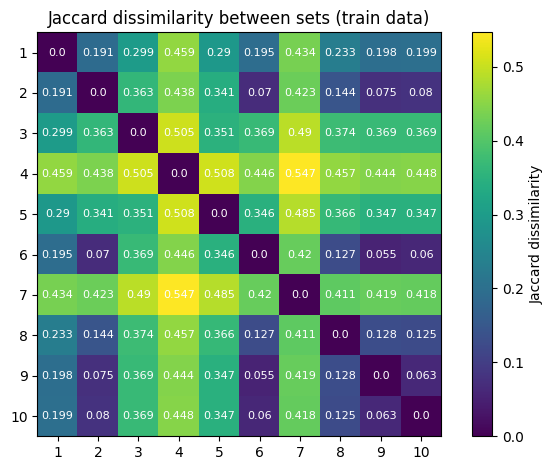

In [191]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
import matplotlib as mpl

"""
vegetables = ["cucumber", "tomato", "lettuce", "asparagus",
              "potato", "wheat", "barley"]
farmers = ["Farmer Joe", "Upland Bros.", "Smith Gardening",
           "Agrifun", "Organiculture", "BioGoods Ltd.", "Cornylee Corp."]

harvest = np.array([[0.8, 2.4, 2.5, 3.9, 0.0, 4.0, 0.0],
                    [2.4, 0.0, 4.0, 1.0, 2.7, 0.0, 0.0],
                    [1.1, 2.4, 0.8, 4.3, 1.9, 4.4, 0.0],
                    [0.6, 0.0, 0.3, 0.0, 3.1, 0.0, 0.0],
                    [0.7, 1.7, 0.6, 2.6, 2.2, 6.2, 0.0],
                    [1.3, 1.2, 0.0, 0.0, 0.0, 3.2, 5.1],
                    [0.1, 2.0, 0.0, 1.4, 0.0, 1.9, 6.3]])
"""
vegetables = [x + 1 for x in range(10)]
farmers = [x + 1 for x in range(10)]
harvest = dftrain

fig, ax = plt.subplots()
im = ax.imshow(harvest)

# Show all ticks and label them with the respective list entries
#ax.set_xticks(range(len(farmers)), labels=farmers,
#              rotation=45, ha="right", rotation_mode="anchor")
ax.set_xticks(range(len(farmers)), labels=farmers,
              rotation=0)
ax.set_yticks(range(len(vegetables)), labels=vegetables)

# Loop over data dimensions and create text annotations.
for i in range(len(vegetables)):
    for j in range(len(farmers)):
        text = ax.text(j, i, np.round(harvest[i, j],3),
                       ha="center", va="center", color="w", size=8)

ax.set_title("Jaccard dissimilarity between sets (train data)")
fig.tight_layout()


cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Jaccard dissimilarity")
plt.savefig("plots/jaccardtrain.eps", format="eps")
plt.show()

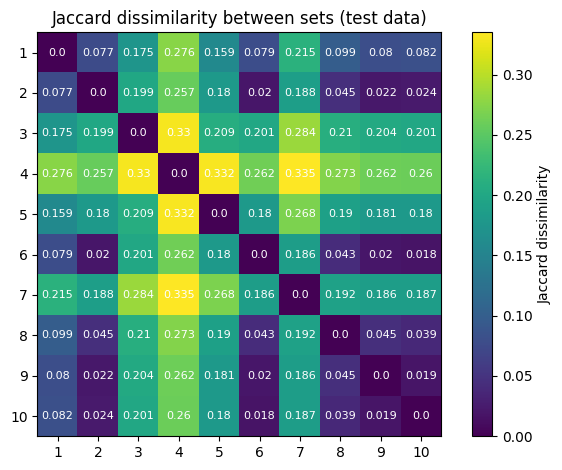

In [192]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
import matplotlib as mpl

"""
vegetables = ["cucumber", "tomato", "lettuce", "asparagus",
              "potato", "wheat", "barley"]
farmers = ["Farmer Joe", "Upland Bros.", "Smith Gardening",
           "Agrifun", "Organiculture", "BioGoods Ltd.", "Cornylee Corp."]

harvest = np.array([[0.8, 2.4, 2.5, 3.9, 0.0, 4.0, 0.0],
                    [2.4, 0.0, 4.0, 1.0, 2.7, 0.0, 0.0],
                    [1.1, 2.4, 0.8, 4.3, 1.9, 4.4, 0.0],
                    [0.6, 0.0, 0.3, 0.0, 3.1, 0.0, 0.0],
                    [0.7, 1.7, 0.6, 2.6, 2.2, 6.2, 0.0],
                    [1.3, 1.2, 0.0, 0.0, 0.0, 3.2, 5.1],
                    [0.1, 2.0, 0.0, 1.4, 0.0, 1.9, 6.3]])
"""
vegetables = [x + 1 for x in range(10)]
farmers = [x + 1 for x in range(10)]
harvest = dftest

fig, ax = plt.subplots()
im = ax.imshow(harvest)

# Show all ticks and label them with the respective list entries
#ax.set_xticks(range(len(farmers)), labels=farmers,
#              rotation=45, ha="right", rotation_mode="anchor")
ax.set_xticks(range(len(farmers)), labels=farmers,
              rotation=0)
ax.set_yticks(range(len(vegetables)), labels=vegetables)

# Loop over data dimensions and create text annotations.
for i in range(len(vegetables)):
    for j in range(len(farmers)):
        text = ax.text(j, i, np.round(harvest[i, j],3),
                       ha="center", va="center", color="w", size=8)

ax.set_title("Jaccard dissimilarity between sets (test data)")
fig.tight_layout()


cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Jaccard dissimilarity")
plt.savefig("plots/jaccardtest.eps", format="eps")
plt.show()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [144]:
import pandas as pd
import numpy as np

names_list_id = [7,5,6,8,9,0,1,2,3,4]
df_solution_without = pd.read_csv("./ga_res/solution_without.txt", sep=";", header=None)
id_help = 0

value = []
approx_value = []

my_str = "1 & 10 & " + str(np.round(0.9728069566104953, 3)) + " & " + str(np.round(0.9948743386243386, 3)) +\
    " & " + str(np.round(0.9941938848188848, 3)) + " & "



df_10 = pd.read_csv("./ga_res/GA_10.txt", sep=";", header=None)
my_mean = np.round(np.mean(np.array(df_10.iloc[:,2])),3)
my_std = np.round(np.std(np.array(df_10.iloc[:,2])),3)
my_str += str(my_mean) + "$\\pm$" + str(my_std) + " & "

tt = 0.9941938848188848
tt_ga = np.mean(np.array(df_10.iloc[:,3]))
relative_error = abs(tt_ga - tt) / abs(tt)

value.append(tt)
approx_value.append(tt_ga)

my_mean = np.round(np.mean(np.array(df_10.iloc[:,3])),3)
my_std = np.round(np.std(np.array(df_10.iloc[:,3])),3)
my_str += str(my_mean) + "$\\pm$" + str(my_std) + " & " + str(np.round(relative_error,4)) + "\\\\"

print(my_str)
for ii in names_list_id:
    df = pd.read_csv("./ga_res/GA_solution_without" + str(ii) + ".txt", sep=";", header=None)

    my_str = str(id_help + 2) + " & 9 (w/o " + str(id_help+1) + ") & " + str(np.round(df_solution_without.iloc[ii,3],3)) + " & "
    my_str += str(np.round(df_solution_without.iloc[ii,4],3)) + " & "
    tt = df_solution_without.iloc[ii,5]
    my_str += str(np.round(tt,3)) + " & "
    my_mean = np.round(np.mean(np.array(df.iloc[:,2])),3)
    my_std = np.round(np.std(np.array(df.iloc[:,2])),3)

    my_str += str(my_mean) + "$\\pm$" + str(my_std)
    tt_ga = np.mean(np.array(df.iloc[:,3]))
    my_mean = np.round(np.mean(np.array(df.iloc[:,3])),3)
    my_std = np.round(np.std(np.array(df.iloc[:,3])),3)

    relative_error = abs(tt_ga - tt) / abs(tt)

    value.append(tt)
    approx_value.append(tt_ga)
    
    #absolute_error = abs(tt_ga - tt)
    my_str += " & " + str(my_mean) + "$\\pm$" + str(my_std) + " & " + str(np.round(relative_error,3)) + "\\\\"
    print(my_str)

    id_help += 1

1 & 10 & 0.973 & 0.995 & 0.994 & 0.971$\pm$0.003 & 0.994$\pm$0.001 & 0.0005\\
2 & 9 (w/o 1) & 0.973 & 0.994 & 0.994 & 0.971$\pm$0.002 & 0.994$\pm$0.0 & 0.0\\
3 & 9 (w/o 2) & 0.969 & 0.993 & 0.993 & 0.966$\pm$0.004 & 0.993$\pm$0.002 & 0.001\\
4 & 9 (w/o 3) & 0.973 & 0.995 & 0.994 & 0.972$\pm$0.002 & 0.994$\pm$0.0 & 0.0\\
5 & 9 (w/o 4) & 0.973 & 0.995 & 0.994 & 0.97$\pm$0.004 & 0.994$\pm$0.001 & 0.001\\
6 & 9 (w/o 5) & 0.973 & 0.995 & 0.994 & 0.972$\pm$0.002 & 0.994$\pm$0.0 & 0.0\\
7 & 9 (w/o 6) & 0.969 & 0.993 & 0.993 & 0.962$\pm$0.007 & 0.992$\pm$0.001 & 0.001\\
8 & 9 (w/o 7) & 0.973 & 0.995 & 0.994 & 0.971$\pm$0.003 & 0.994$\pm$0.001 & 0.0\\
9 & 9 (w/o 8) & 0.973 & 0.994 & 0.994 & 0.971$\pm$0.004 & 0.994$\pm$0.001 & 0.0\\
10 & 9 (w/o 9) & 0.972 & 0.993 & 0.993 & 0.967$\pm$0.007 & 0.992$\pm$0.002 & 0.001\\
11 & 9 (w/o 10) & 0.973 & 0.995 & 0.994 & 0.97$\pm$0.006 & 0.994$\pm$0.002 & 0.001\\


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


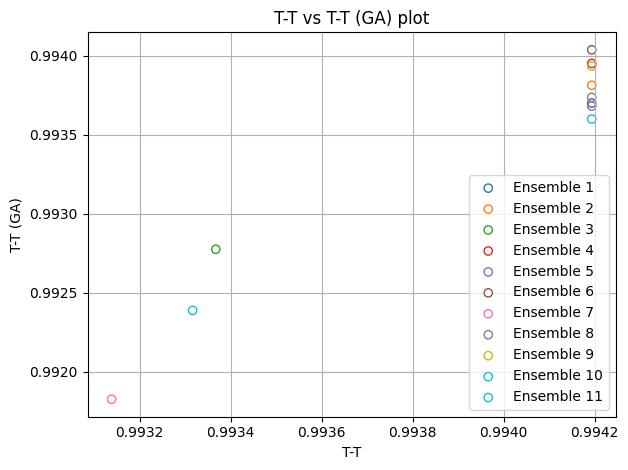

In [168]:

import numpy as np
import matplotlib.pyplot as plt

true_values = np.array(value)
estimated_values = np.array(approx_value)

# Example labels: integers 1..10
labels = np.array([x + 1 for x in range(len(true_values))])

fig, ax = plt.subplots()

unique_labels = np.unique(labels)
cmap = plt.get_cmap("tab10")

for i, lbl in enumerate(unique_labels):
    mask = labels == lbl
    ax.scatter(
        true_values[mask],
        estimated_values[mask],
        color=cmap(i),
        facecolors='none',
        label=f"Ensemble {lbl}",
        marker='o'
    )

ax.set_xlabel("T-T")
ax.set_ylabel("T-T (GA)")
ax.set_title("T-T vs T-T (GA) plot")

ax.grid(True)
ax.legend()

plt.tight_layout()
plt.savefig("plots/ttvsttga.eps", format="eps")
plt.show()


In [208]:
def conditional_probability(l1, l2):
    common_indices = [i for i, (a, b) in enumerate(zip(l1, l2)) if a == b and a == True]
    denominator1 = [i for i, (a, b) in enumerate(zip(l1, l2)) if a == True]
    denominator2 = [i for i, (a, b) in enumerate(zip(l1, l2)) if b == True]
    return common_indices, denominator1, denominator2

def calc_conditional_probability_matrix(all_ok_guess):
    diff_numpy1 = np.zeros((len(all_ok_guess), len(all_ok_guess)))
    diff_numpy2 = np.zeros((len(all_ok_guess), len(all_ok_guess)))
    for a in range(len(all_ok_guess)):
        for b in range(len(all_ok_guess)):
            common_indices, denominator1, denominator2 = conditional_probability(all_ok_guess[a], all_ok_guess[b])
            diff_numpy1[a,b] = len(common_indices) / len(denominator1)
            diff_numpy2[a,b] = len(common_indices) / len(denominator2)
    return diff_numpy1, diff_numpy2



In [214]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib
import matplotlib as mpl

def plot_2d_array(xxx, plot_title, legend_title, save_file = None):
    vegetables = [x + 1 for x in range(10)]
    farmers = [x + 1 for x in range(10)]
    harvest = xxx
    
    fig, ax = plt.subplots()
    im = ax.imshow(harvest)
    
    # Show all ticks and label them with the respective list entries
    #ax.set_xticks(range(len(farmers)), labels=farmers,
    #              rotation=45, ha="right", rotation_mode="anchor")
    ax.set_xticks(range(len(farmers)), labels=farmers,
                  rotation=0)
    ax.set_yticks(range(len(vegetables)), labels=vegetables)
    
    # Loop over data dimensions and create text annotations.
    for i in range(len(vegetables)):
        for j in range(len(farmers)):
            text = ax.text(j, i, np.round(harvest[i, j],3),
                           ha="center", va="center", color="w", size=8)
    
    ax.set_title(plot_title)
    fig.tight_layout()
    
    
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(legend_title)
    if save_file is not None:
        plt.savefig(save_file, format="eps")
    plt.show()

In [210]:
names_list_id = [7,5,6,8,9,0,1,2,3,4]
numpy_test_order = [numpy_test[i] for i in names_list_id]
numpy_train_order = [numpy_train[i] for i in names_list_id]

dftrain1, dftrain2 = calc_conditional_probability_matrix(numpy_train_order)
dftest1, dftest2 = calc_conditional_probability_matrix(numpy_test_order)

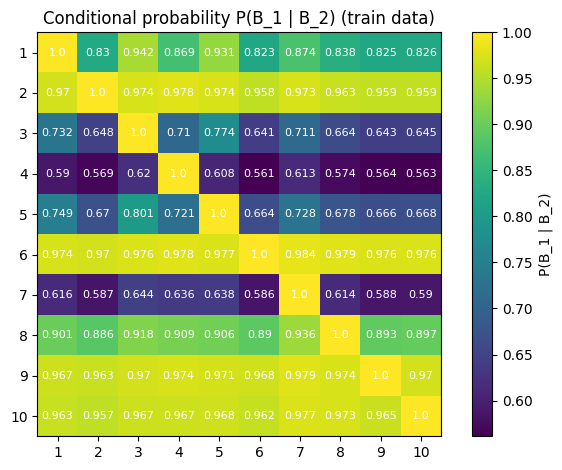

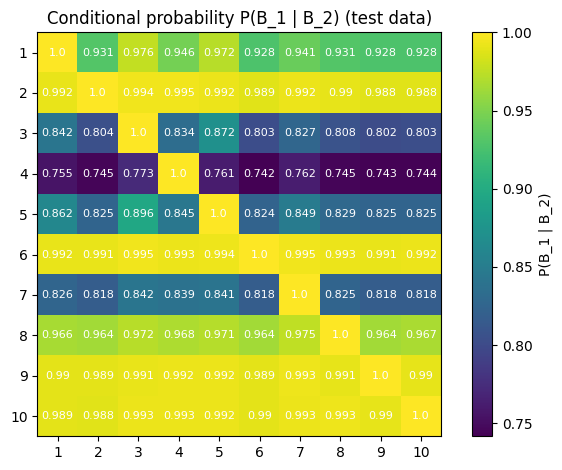

In [221]:
plot_2d_array(dftrain2, "Conditional probability P(B_1 | B_2) (train data)", "P(B_1 | B_2)", "plots/conditionaltrain.eps")
plot_2d_array(dftest2, "Conditional probability P(B_1 | B_2) (test data)", "P(B_1 | B_2)", "plots/conditionaltest.eps")


In [233]:
common_indices, denominator1, denominator2 = conditional_probability(numpy_test_order[0], numpy_test_order[1])
print(len(common_indices) / len(denominator2))
common_indices, denominator1, denominator2 = conditional_probability(numpy_test_order[1], numpy_test_order[6])
print(len(common_indices) / len(denominator2))

0.9305074580665131
0.9919971837596808


In [204]:
common_indices, denumarotor1, denumarotor2 = conditional_probability([True, False, True, False, False, True], 
                                                                     [True, False, True, True, False, True])
print(common_indices)
print(denumarotor1)
print(denumarotor2)
print(len(common_indices)/len(denumarotor1))
print(len(common_indices)/len(denumarotor2))

[0, 2, 5]
[0, 2, 5]
[0, 2, 3, 5]
1.0
0.75


In [179]:
print(len(numpy_test[0]))
print(sum(1 for x in numpy_test[0] if x is True))


157248
155516


In [182]:
dftrain

array([[0.        , 0.19056549, 0.29919029, 0.45851656, 0.29048713,
        0.19474405, 0.4340916 , 0.23260001, 0.19780744, 0.19935565],
       [0.19056549, 0.        , 0.36277272, 0.43848819, 0.34144324,
        0.06961454, 0.42299984, 0.14379003, 0.0750207 , 0.08006351],
       [0.29919029, 0.36277272, 0.        , 0.50521268, 0.35066545,
        0.36874852, 0.48982529, 0.3736569 , 0.36911421, 0.36894552],
       [0.45851656, 0.43848819, 0.50521268, 0.        , 0.50772465,
        0.4458847 , 0.54653789, 0.45706358, 0.44430829, 0.44802057],
       [0.29048713, 0.34144324, 0.35066545, 0.50772465, 0.        ,
        0.34621512, 0.48517227, 0.36630701, 0.3468619 , 0.34667921],
       [0.19474405, 0.06961454, 0.36874852, 0.4458847 , 0.34621512,
        0.        , 0.41971818, 0.12708843, 0.05465412, 0.06002622],
       [0.4340916 , 0.42299984, 0.48982529, 0.54653789, 0.48517227,
        0.41971818, 0.        , 0.41094269, 0.41917576, 0.41785703],
       [0.23260001, 0.14379003, 0.3736569